In [ ]:
import qiskit
print("Kernel working")

Kernel working


In [ ]:
# ===============================
# CORE LIBRARIES
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
from data_loader import load_data
from preprocessing import preprocess_data
from feature_selection import select_top_features
from utils import print_section

In [ ]:
import importlib
import data_loader

importlib.reload(data_loader)

<module 'data_loader' from 'c:\\Quantum_Heart\\src\\data_loader.py'>

In [ ]:
from data_loader import load_data
X_train, X_test, y_train, y_test, scaler = load_data()

In [ ]:
print_section("Loading Dataset")

# Directly call your pipeline
X_train, X_test, y_train, y_test, scaler = load_data()

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)
print("Number of Features:", X_train.shape[1])

print("\nTraining Target Distribution:")
print(pd.Series(y_train).value_counts())


Loading Dataset
Training Shape: (242, 13)
Testing Shape: (61, 13)
Number of Features: 13

Training Target Distribution:
1    132
0    110
Name: count, dtype: int64


In [ ]:
print_section("Raw Dataset Inspection")

import os

# Move from src → project root
PROJECT_ROOT = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "cleveland.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.head()



Raw Dataset Inspection
Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
print_section("Missing Values Check")

missing = df.isnull().sum()
print(missing)


Missing Values Check
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64



Target Distribution


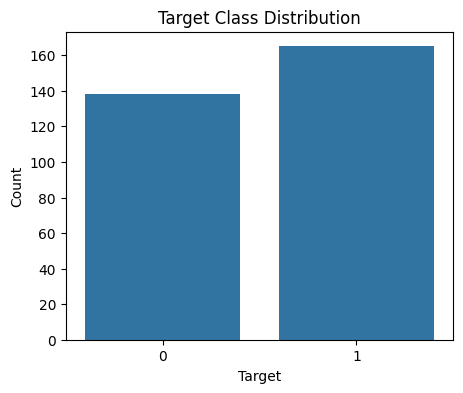

In [ ]:
# Target Distribution
print_section("Target Distribution")

plt.figure(figsize=(5,4))
sns.countplot(x=df["target"])
plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()



Correlation Matrix


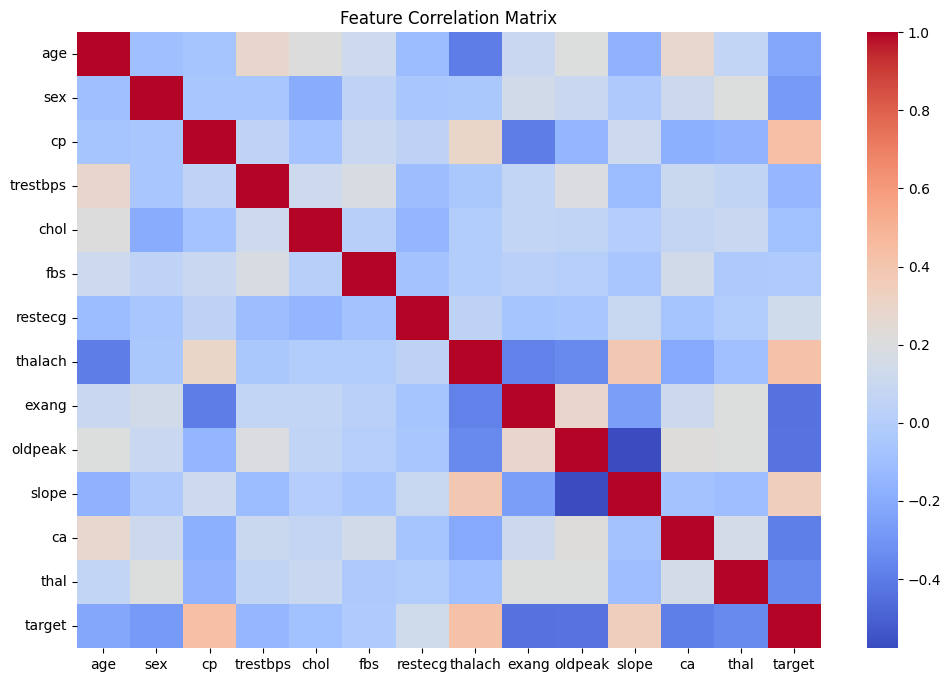

In [ ]:
print_section("Correlation Matrix")

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Matrix")
plt.show()


In [ ]:
print_section("Feature Statistics")
df.describe()


Feature Statistics


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000
